In [35]:
import json
import os

import pandas as pd
import networkx as nx

from groq import Groq
from pathlib import Path

pd.set_option("display.max_columns", None)

In [36]:
DATASET_DIR = "./dataset"

SERVICES_FILE       = f"{DATASET_DIR}/services.json"
CLUSTERS_FILE       = f"{DATASET_DIR}/cluster_summary.json"
ALERTS_FILE         = f"{DATASET_DIR}/alerts_sample.jsonl"
INCIDENTS_FILE      = f"{DATASET_DIR}/incidents_history.json"

with open(SERVICES_FILE, "r", encoding="utf-8") as f:
    services_data = json.load(f)

with open(CLUSTERS_FILE, "r", encoding="utf-8") as f:
    cluster_summary = json.load(f)

with open(INCIDENTS_FILE, "r", encoding="utf-8") as f:
    incidents_history = json.load(f)["incidents"]

alerts = []
with open(ALERTS_FILE, "r", encoding="utf-8") as f:
    for line in f:
        alerts.append(json.loads(line))

print("Services:", len(services_data["services"]))
print("Stores:",   len(services_data["stores"]))
print("Alerts:",   len(alerts))
print("Clusters:", len(cluster_summary["clusters"]))
print("History incidents:", len(incidents_history))


Services: 10
Stores: 4
Alerts: 20
Clusters: 2
History incidents: 29


In [37]:
G = nx.DiGraph()

for svc in services_data["services"]:

    G.add_node(
        svc["name"],
        node_type="service",
        criticality=svc["criticality"]
    )

for store in services_data["stores"]:

    G.add_node(
        store["name"],
        node_type="store",
        criticality=store["criticality"]
    )

for edge in services_data["edges"]:

    G.add_edge(
        edge["from"],
        edge["to"],
        edge_type=edge["type"]
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 14
Edges: 17


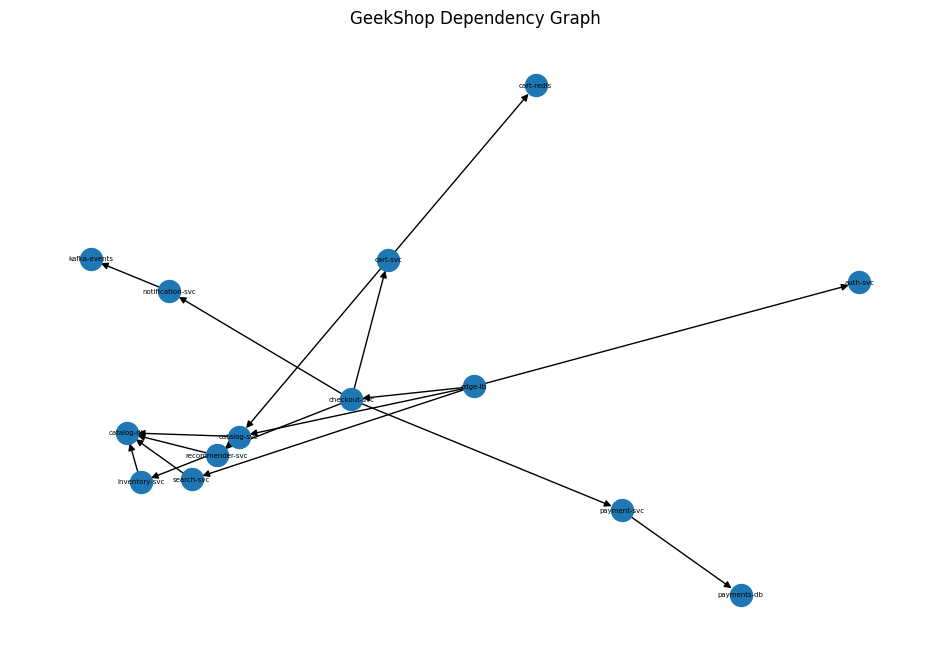

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx(
    G,
    pos,
    node_size=250,
    font_size=5,
    arrows=True
)

plt.title("GeekShop Dependency Graph")
plt.axis("off")
plt.show()

In [39]:
alert_lookup = {
    a["id"]: a
    for a in alerts
}

print("Lookup ready")

Lookup ready


In [40]:
def rca_pagerank(
    cluster_services,
    graph,
    alpha=0.85
):
    """PageRank on REVERSED subgraph.
    Service depended-on by many callers → higher score → culprit candidate.
    """
    sub = graph.subgraph(cluster_services).copy()

    if len(sub.nodes()) == 0:
        return {}

    # Reverse: A→B becomes B→A so callee receives votes from callers
    #reverse = sub.reverse(copy=True)

    return nx.pagerank(sub, alpha=alpha)


In [41]:
def earliest_alert_by_service(
    alerts,
    cluster_services
):

    earliest = {}

    for alert in alerts:

        svc = alert["service"]

        if svc not in cluster_services:
            continue

        ts = alert["ts"]

        if svc not in earliest:
            earliest[svc] = ts

        elif ts < earliest[svc]:
            earliest[svc] = ts

    return earliest

In [42]:
def rca_combined(
    cluster,
    alerts,
    graph
):

    cluster_services = cluster["services"]

    pr_scores = rca_pagerank(
        cluster_services,
        graph
    )

    earliest = earliest_alert_by_service(
        alerts,
        cluster_services
    )

    sorted_time = sorted(
        earliest.items(),
        key=lambda x: x[1]
    )

    n = len(sorted_time)

    ts_score = {
        svc: 1 - i/max(n-1,1)
        for i,(svc,_) in enumerate(sorted_time)
    }

    pr_max = max(
        pr_scores.values()
    ) if pr_scores else 1

    combined = []

    for svc in cluster_services:

        score = (
            0.6 * (
                pr_scores.get(svc,0)
                / pr_max
            )
            +
            0.4 * ts_score.get(
                svc,
                0
            )
        )

        combined.append(
            (svc, round(score,4))
        )

    combined.sort(
        key=lambda x:x[1],
        reverse=True
    )

    return combined

In [43]:
def incident_similarity(cluster, history_item):
    """0-1 score: how similar a past incident is to the current cluster.
    Checks root_cause_service overlap, service overlap, and severity.
    """
    score = 0.0

    # Root cause service present in current cluster → strong signal
    if history_item["root_cause_service"] in cluster["services"]:
        score += 0.4

    # Service overlap (capped at 0.4)
    overlap = set(cluster["services"]) & set(history_item["services_involved"])
    score += min(0.4, 0.2 * len(overlap))

    # Severity match
    if cluster.get("max_severity") == history_item.get("severity"):
        score += 0.2

    return min(score, 1.0)


def top_k_similar(cluster, history, k=3):
    """Return top-k most similar past incidents with _similarity score."""
    scored = [
        (item, incident_similarity(cluster, item))
        for item in history
    ]
    scored.sort(key=lambda x: -x[1])
    return [
        {**item, "_similarity": s}
        for item, s in scored[:k]
        if s > 0.2
    ]


# Quick smoke-test on first cluster
sample_cluster = cluster_summary["clusters"][0]
top3 = top_k_similar(sample_cluster, incidents_history)
print(f"Top-{len(top3)} similar incidents for {sample_cluster['cluster_id']}:")
for inc in top3:
    print(f"  {inc['id']} | sim={inc['_similarity']:.2f} | {inc['root_cause_class']} | {inc['summary'][:60]}")


Top-3 similar incidents for c-001:
  INC-2025-11-08 | sim=0.80 | connection_pool_exhaustion | Payment-svc v3.2 deploy at 09:42 leak DB pool. Pool 50/50 us
  INC-2026-03-20 | sim=0.80 | ddos | Volumetric DDoS 5x normal traffic. Edge-lb saturate, all ups
  INC-2025-08-17 | sim=0.60 | tls_expiry | TLS cert expired sáng. Cert renewal automation fail im lặng 


In [44]:
from groq import Groq

GROQ_API_KEY = "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"

client = Groq(
    api_key=GROQ_API_KEY
)

print("Groq Ready")

Groq Ready


In [45]:
RCA_PROMPT = """
You are a senior SRE diagnosing a production incident at GeekShop e-commerce.

# Cluster information
Cluster ID: {cluster_id}
Services with alerts: {services}
Alert fingerprints: {fingerprints}

# Top root-cause candidates (graph RCA, ranked)
{candidates}

# Similar past incidents
{similar_incidents_block}

# Service dependency graph
{graph}

# Task
Based on all the above:
1. Pick the single most likely root_cause service (must be from the services list above)
2. Classify root_cause_class — one of: connection_pool_exhaustion, slow_query,
   memory_leak, rebalance_storm, deadlock, network_partition, bad_deploy,
   config_push, tls_expiry, ddos, other
3. Confidence 0.0-1.0
4. Suggest 1-3 actions ordered by priority
5. Brief reasoning (2-3 sentences)
6. List the similar incident IDs you referenced

Return ONLY valid JSON:
{{
    "root_cause": "service-name",
    "class": "connection_pool_exhaustion",
    "confidence": 0.0,
    "actions": ["action1", "action2"],
    "reasoning": "2-3 sentence explanation",
    "similar_incidents": ["INC-XXXX-XX-XX"]
}}
"""


In [46]:
def build_graph_summary(
    cluster,
    graph
):

    sub = graph.subgraph(
        cluster["services"]
    )

    lines = []

    for u,v in sub.edges():

        lines.append(
            f"{u} -> {v}"
        )

    return "\n".join(lines)

In [47]:
def call_groq_rca(
    cluster,
    candidates,
    graph,
    history
):
    # Retrieve similar past incidents
    similar = top_k_similar(cluster, history, k=3)

    if similar:
        similar_block = "\n".join(
            f"- {i['id']}: root_cause={i['root_cause_service']} "
            f"({i['root_cause_class']}) | sim={i['_similarity']:.2f} | "
            f"{i['summary']} | fix: {i['remediation']}"
            for i in similar
        )
    else:
        similar_block = "(no similar incidents found)"

    candidate_text = "\n".join(
        f"{i+1}. {svc} (score: {score:.3f})"
        for i, (svc, score) in enumerate(candidates[:5])
    )

    graph_text = build_graph_summary(cluster, graph)

    prompt = RCA_PROMPT.format(
        cluster_id=cluster["cluster_id"],
        services=", ".join(cluster["services"]),
        fingerprints="\n".join(cluster.get("fingerprints", [])),
        candidates=candidate_text,
        similar_incidents_block=similar_block,
        graph=graph_text
    )

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        temperature=0.2,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": "Output valid JSON only."},
            {"role": "user",   "content": prompt}
        ]
    )

    content = response.choices[0].message.content
    return json.loads(content)


In [48]:
ALLOWED_CLASSES = {
    "connection_pool_exhaustion",
    "slow_query",
    "memory_leak",
    "rebalance_storm",
    "deadlock",
    "network_partition",
    "bad_deploy",
    "config_push",
    "tls_expiry",
    "ddos",
    "other"
}

def validate_llm_output(
    output,
    cluster
):

    if output["root_cause"] \
        not in cluster["services"]:
        return False

    if output["class"] \
        not in ALLOWED_CLASSES:
        return False

    return True

In [49]:
def run_rca(
    cluster,
    alerts,
    graph,
    history
):
    """Full RCA pipeline for one cluster:
    Graph RCA → incident retrieval → LLM enrich → validate → fallback.
    """
    candidates = rca_combined(cluster, alerts, graph)

    if not candidates:
        return {
            "cluster_id": f"{cluster['cluster_id']}-000",
            "graph_top3": [],
            "root_cause": None,
            "class": "other",
            "confidence": 0,
            "actions": ["Investigate manually"],
            "reasoning": "No candidates found",
            "similar_incidents": [],
            "method": "no-candidates"
        }

    try:
        llm_out = call_groq_rca(cluster, candidates, graph, history)

        valid = validate_llm_output(llm_out, cluster)
        if not valid:
            raise ValueError("Invalid LLM output")

        return {
            "cluster_id":        f"{cluster['cluster_id']}-000",
            "graph_top3":        [[s, sc] for s, sc in candidates[:3]],
            "root_cause":        llm_out["root_cause"],
            "class":             llm_out["class"],
            "confidence":        llm_out["confidence"],
            "actions":           llm_out["actions"],
            "reasoning":         llm_out["reasoning"],
            "similar_incidents": llm_out.get("similar_incidents", []),
            "method":            "graph+groq"
        }

    except Exception as e:
        # Fallback: use graph-only top-1 + rule-based history retrieval
        similar = top_k_similar(cluster, history, k=1)
        fallback_class = similar[0]["root_cause_class"] if similar else "other"
        fallback_action = similar[0]["remediation"] if similar else "Investigate manually"
        similar_ids = [similar[0]["id"]] if similar else []

        return {
            "cluster_id":        f"{cluster['cluster_id']}-000",
            "graph_top3":        [[s, sc] for s, sc in candidates[:3]],
            "root_cause":        candidates[0][0],
            "class":             fallback_class,
            "confidence":        candidates[0][1],
            "actions":           [fallback_action],
            "reasoning":         f"LLM unavailable ({e}); rule-based fallback from history.",
            "similar_incidents": similar_ids,
            "method":            "graph+history-fallback"
        }


In [50]:
results = []

for cluster in cluster_summary["clusters"]:
    result = run_rca(cluster, alerts, G, incidents_history)
    results.append(result)

pd.DataFrame(results)


,cluster_id,graph_top3,root_cause,class,confidence,actions,reasoning,similar_incidents,method
0,c-001-000,"[[payment-svc, 0.9911], [checkout-svc, 0.92], ...",payment-svc,connection_pool_exhaustion,0.95,"[Rollback to previous version of payment-svc, ...",The high score of payment-svc in the root-caus...,[INC-2025-11-08],graph+groq
1,c-002-000,"[[recommender-svc, 1.0]]",recommender-svc,memory_leak,0.80,[Investigate recent code changes for potential...,The high CPU utilization warning and past inci...,"[INC-2025-08-02, INC-2025-10-28, INC-2026-03-07]",graph+groq


In [51]:
output = {
    "clusters_analyzed":
        len(results),

    "results":
        results
}

Path("results").mkdir(
    exist_ok=True
)

with open(
    "results/rca_output.json",
    "w"
) as f:

    json.dump(
        output,
        f,
        indent=2
    )

print(
    "Saved results/rca_output.json"
)

Saved results/rca_output.json


In [52]:
with open(
    "results/rca_output.json"
) as f:

    print(f.read())

{
  "clusters_analyzed": 2,
  "results": [
    {
      "cluster_id": "c-001-000",
      "graph_top3": [
        [
          "payment-svc",
          0.9911
        ],
        [
          "checkout-svc",
          0.92
        ],
        [
          "cart-svc",
          0.7511
        ]
      ],
      "root_cause": "payment-svc",
      "class": "connection_pool_exhaustion",
      "confidence": 0.95,
      "actions": [
        "Rollback to previous version of payment-svc",
        "Scale up the database connection pool",
        "Add monitoring alert for connection pool usage"
      ],
      "reasoning": "The high score of payment-svc in the root-cause candidates and the critical alert for db_connection_pool_used_ratio suggest a connection pool exhaustion issue, similar to INC-2025-11-08. The downstream services such as checkout-svc are also experiencing issues, which is consistent with this diagnosis. The high confidence is due to the strong similarity with the past incident.",
      "